In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
       for filename in filenames:
           print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df = df.drop("CustomerID" , axis = 1)
df['Gender'] = df['Gender'].map({"Male" : 0 , "Female" : 1})
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [5]:
Scaler = MinMaxScaler()
df = Scaler.fit_transform(df)

In [6]:
MSE = []
K = range(1 ,11)
for k in K:
  KM = KMeans(n_clusters= k)
  KM.fit_predict(df)
  MSE.append(KM.inertia_)

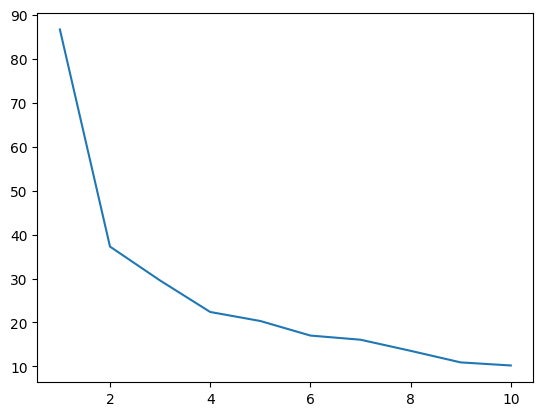

In [7]:
plt.plot(range(1 , 11) , MSE)

In [8]:
KM = KMeans(n_clusters= 4)

In [9]:
y_pred = KM.fit_predict(df)

In [10]:
df = pd.DataFrame(df , columns = ['Gender' , 'Age',	'Annual Income (k$)',	'Spending Score (1-100)'])

In [11]:
df['Cluster'] = y_pred

In [12]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0.0,0.019231,0.000000,0.387755,2
1,0.0,0.057692,0.000000,0.816327,2
2,1.0,0.038462,0.008197,0.051020,0
3,1.0,0.096154,0.008197,0.775510,3
4,1.0,0.250000,0.016393,0.397959,3


<Axes: >

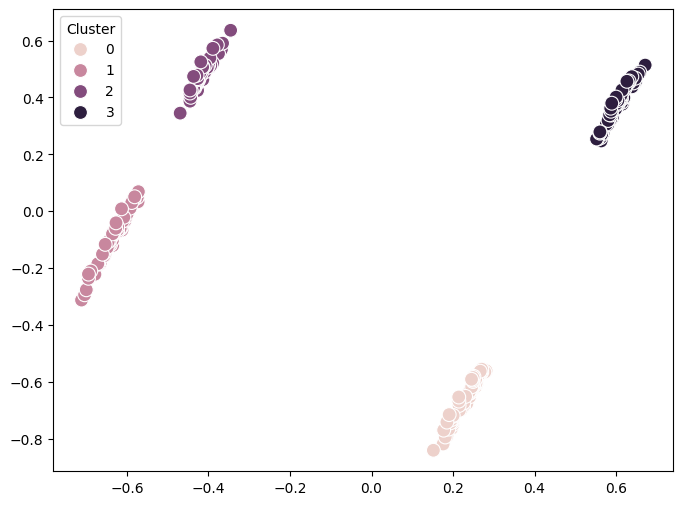

In [13]:
from sklearn.decomposition import PCA
import seaborn as sns
pca = PCA(n_components= 2)
df_scaled = Scaler.fit_transform(df)
df_reduced = pca.fit_transform(df_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_reduced[: , 0] , y=df_reduced[:,1], hue=df['Cluster'],s=100)

In [14]:
aggo = AgglomerativeClustering(n_clusters= 4)
y_pred = aggo.fit_predict(df)

In [15]:
df['Cluster'] = y_pred

In [16]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0.0,0.019231,0.000000,0.387755,3
1,0.0,0.057692,0.000000,0.816327,3
2,1.0,0.038462,0.008197,0.051020,2
3,1.0,0.096154,0.008197,0.775510,1
4,1.0,0.250000,0.016393,0.397959,1
...,...,...,...,...,...
195,1.0,0.326923,0.860656,0.795918,1
196,1.0,0.519231,0.909836,0.275510,2
197,0.0,0.269231,0.909836,0.744898,3
198,0.0,0.269231,1.000000,0.173469,0


<Axes: >

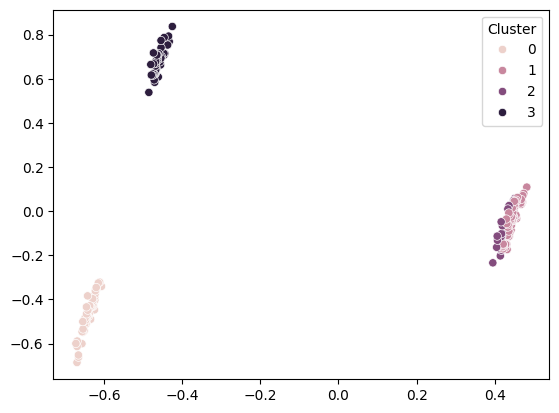

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components= 2)
scaled_df = Scaler.fit_transform(df)
df_reduced = pca.fit_transform(scaled_df)
sns.scatterplot(x = df_reduced[: , 0] , y = df_reduced[: , 1] ,hue=df['Cluster'])